In [1]:
from git import Repo
import base
import os

folder_path = "."
project_name = "ifg-py"
# commit_hash = "a420a50160b02753db1491ec27c14ed7302115e5"
commit_hash = "d406b9a337aeb1218704895d82edbb6cd0396c4d"

repo = Repo(os.path.join(folder_path, project_name))
current_commit = repo.commit(commit_hash)
before_commit = current_commit.parents[0] if current_commit.parents else None

print(f"Current commit: {current_commit.hexsha}")
print(f"Before commit: {before_commit.hexsha if before_commit else 'None'}")

Current commit: d406b9a337aeb1218704895d82edbb6cd0396c4d
Before commit: fdbedb33bd2f086db0a511f5902b7a9923b474a5


Processing file: ifg_py/ifg.py
Processing file: ifg_py/ifg.py

=== Skipped files ===

=== File Diffs ===

modified: ifg_py/ifg.py -> ifg_py/ifg.py
  [Constant] line 9: 'NUM:1e+25' -> [Constant] line 9: 'NUM:10000000000.0'

=== ifg_py/ifg.py ===
Nodes: 2001, Edges: 2729


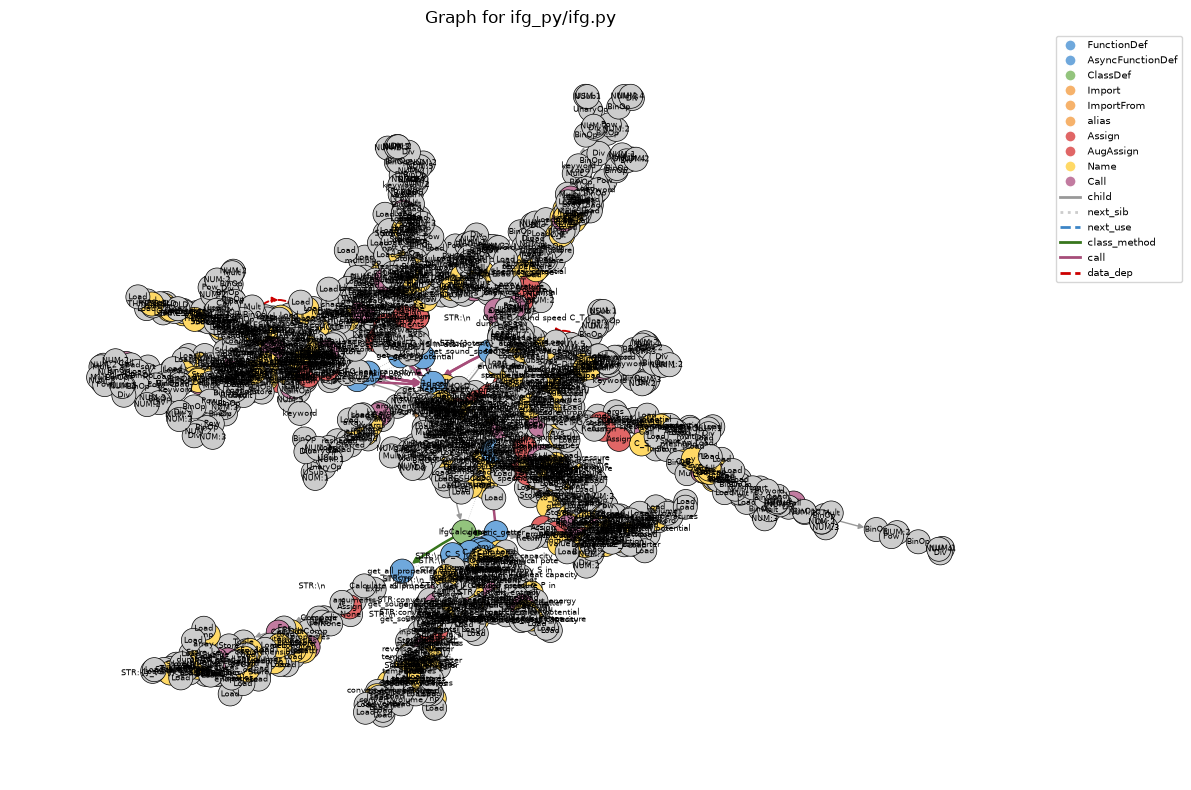

In [2]:
builder_current = base.Builder(folder_path, project_name, current_commit.hexsha)
builder_before = base.Builder(folder_path, project_name, before_commit.hexsha)

file_diffs, skipped = base.unify_commit(builder_before, builder_current, files=None)

print(f"\n=== Skipped files ===")
for file_path in skipped:
    print(f"- {file_path}")

print(f"\n=== File Diffs ===")
for fd in file_diffs:
    print(f"\n{fd.kind}: {fd.path_before} -> {fd.path_current}")
    for b, c in fd.modified_pairs:
        db, dc = fd.gb.G.nodes[b], fd.gc.G.nodes[c]
        print(f"  [{db['type']}] line {db['lineno']}: '{db['token']}' -> [{dc['type']}] line {dc['lineno']}: '{dc['token']}'")

# print(f"\n=== Current Graphs ===")

# builder_current.build()

for file_path, graph in builder_current.graphs.items():
    print(f"\n=== {file_path} ===")
    print(f"Nodes: {graph.G.number_of_nodes()}, Edges: {graph.G.number_of_edges()}")
    graph.visualize()


=== ifg_py/ifg.py ===
Nodes: 2001, Edges: 2729


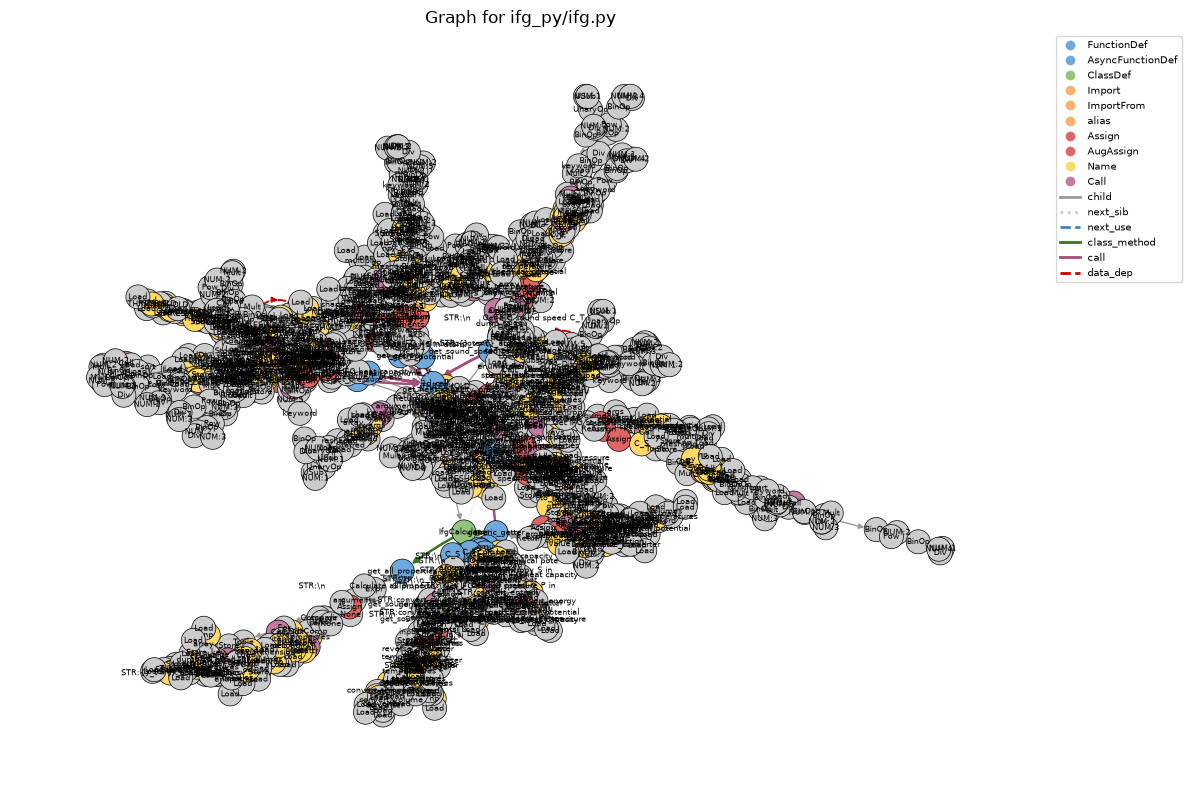

In [3]:
# builder_before.build()

for file_path, graph in builder_before.graphs.items():
    print(f"\n=== {file_path} ===")
    print(f"Nodes: {graph.G.number_of_nodes()}, Edges: {graph.G.number_of_edges()}")
    graph.visualize()

In [4]:
for file_path in builder_current.graphs.keys():
    gb = builder_before.graphs[file_path]
    gc = builder_current.graphs[file_path]

    status_before, status_current, modified_pairs = base.unify_graphs(gb, gc)

    print(f"\n=== {file_path} ===")
    # print(f"Status before: {status_before}")
    # print(f"Status current: {status_current}")
    print("\nModified pairs:")
    for b, c in modified_pairs:
        db, dc = gb.G.nodes[b], gc.G.nodes[c]
        print(f"  [{db['type']}] line {db['lineno']}: '{db['token']}' -> [{dc['type']}] line {dc['lineno']}: '{dc['token']}'")


=== ifg_py/ifg.py ===

Modified pairs:
  [Constant] line 9: 'NUM:1e+25' -> [Constant] line 9: 'NUM:10000000000.0'


In [5]:
U = base.build_union_graph(file_diffs)
print(base.summarize_union(U))

for uid, d in U.nodes(data=True):
    if d["changed"]:
        print(uid, d["status"], "|", d["type_before"], repr(d["token_before"]), "->", d["type_after"], repr(d["token_after"]))

{'nodes': {'modified_context': 3, 'unchanged': 1997, 'modified': 1}, 'edges_changed': {}, 'n_nodes': 2001, 'n_edges': 2719}
u0 modified_context | Root '' -> Root ''
u1 modified_context | Module '' -> Module ''
u15 modified_context | Assign '' -> Assign ''
u18 modified | Constant 'NUM:1e+25' -> Constant 'NUM:10000000000.0'
